<a href="https://colab.research.google.com/github/valeriavasquezv/valeriavasquez-portfolio/blob/main/Telecom2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telecom 2


In [1]:
import pandas as pd

In [2]:
datos = pd.read_csv('https://raw.githubusercontent.com/valeriavasquezv/valeriavasquez-portfolio/refs/heads/main/telecomx_limpio.csv')

In [3]:
datos.tail()

,customerID,Churn,customer,phone,internet,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
7038,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...",One year,No,Mailed check,55.15,742.90
7039,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...",Month-to-month,Yes,Electronic check,85.10,1873.70
7040,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...",Month-to-month,Yes,Mailed check,50.30,92.75
7041,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...",Two year,No,Mailed check,67.85,4627.65
7042,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'No', 'MultipleLines': 'No ph...","{'InternetService': 'DSL', 'OnlineSecurity': '...",Two year,No,Electronic check,59.00,3707.60


In [28]:
# Ver cuántos NaN tienes
print(X_train.isnull().sum().sort_values(ascending=False))

Charges.Total                            10
Charges.Monthly                           0
SeniorCitizen                             0
tenure                                    0
Contract_One year                         0
Contract_Two year                         0
PaperlessBilling_Yes                      0
PaymentMethod_Credit card (automatic)     0
PaymentMethod_Electronic check            0
PaymentMethod_Mailed check                0
gender_Male                               0
Partner_Yes                               0
Dependents_Yes                            0
PhoneService_Yes                          0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet ser

In [29]:
# Rellenar NaN con 0 (opción común en este dataset)
X_train["Charges.Total"] = X_train["Charges.Total"].fillna(0)
X_test["Charges.Total"] = X_test["Charges.Total"].fillna(0)

In [4]:
import ast

# Convertir de string a diccionario real
datos["customer"] = datos["customer"].apply(ast.literal_eval)
datos["phone"] = datos["phone"].apply(ast.literal_eval)
datos["internet"] = datos["internet"].apply(ast.literal_eval)

In [5]:
customer_expandido = pd.json_normalize(datos["customer"])
phone_expandido = pd.json_normalize(datos["phone"])
internet_expandido = pd.json_normalize(datos["internet"])

datos = pd.concat([
    datos.drop(columns=["customer", "phone", "internet"]),
    customer_expandido, phone_expandido, internet_expandido], axis=1)

datos.shape

(7043, 21)

In [6]:
datos = datos.drop(columns=["customerID"])

In [7]:
# Variable Objetivo

X = datos.drop("Churn", axis=1)
y = datos["Churn"]

In [8]:
# id de Variables categóricas

X.dtypes

,0
Contract,object
PaperlessBilling,object
PaymentMethod,object
Charges.Monthly,float64
Charges.Total,float64
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64


In [9]:
X = datos.drop("Churn", axis=1)
y = datos["Churn"]

X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.shape

(7043, 30)

In [10]:
datos["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [11]:
X = X_encoded
y = datos["Churn"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train.shape, X_test.shape

((4930, 30), (2113, 30))

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
datos_corr = X_encoded.copy()

# Verificamos qué contiene y
print(type(y))
print(y.head())

# Agregamos la variable objetivo
datos_corr["Churn"] = y.values

# Verificamos que sí se agregó
print(datos_corr.columns)

<class 'pandas.core.series.Series'>
0     No
1     No
2    Yes
3    Yes
4    Yes
Name: Churn, dtype: object
Index(['Charges.Monthly', 'Charges.Total', 'SeniorCitizen', 'tenure',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Churn'],
      dtype='object')


In [22]:
# Convertir Churn a numérico
datos_corr["Churn"] = datos_corr["Churn"].map({"No": 0, "Yes": 1})

# Seleccionar columnas numéricas
datos_corr = datos_corr.select_dtypes(include=["number", "bool"])

# Rellenar nulos por seguridad
datos_corr = datos_corr.fillna(0)

# Calcular correlación
corr_matrix = datos_corr.corr()

corr_churn = corr_matrix["Churn"].sort_values(ascending=False)

corr_churn

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
Charges.Monthly,0.193356
PaperlessBilling_Yes,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102
PhoneService_Yes,0.011942


##Ternure vs Churn


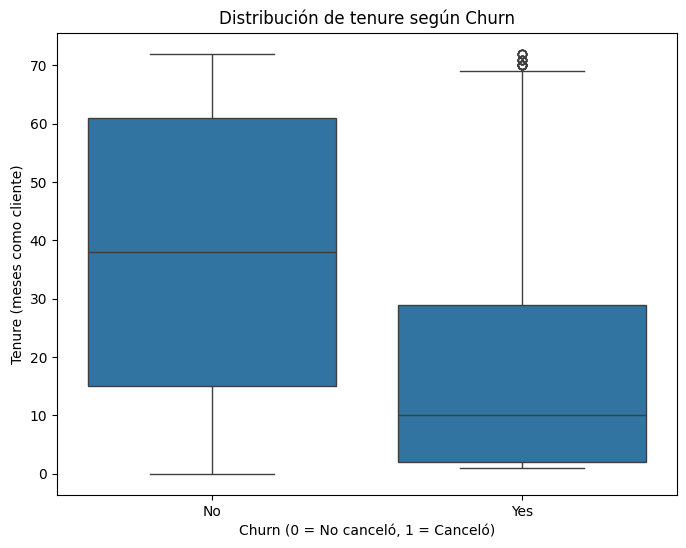

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x=datos["Churn"], y=datos["tenure"])
plt.title("Distribución de tenure según Churn")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Tenure (meses como cliente)")
plt.show()

## Charges total vs Churn

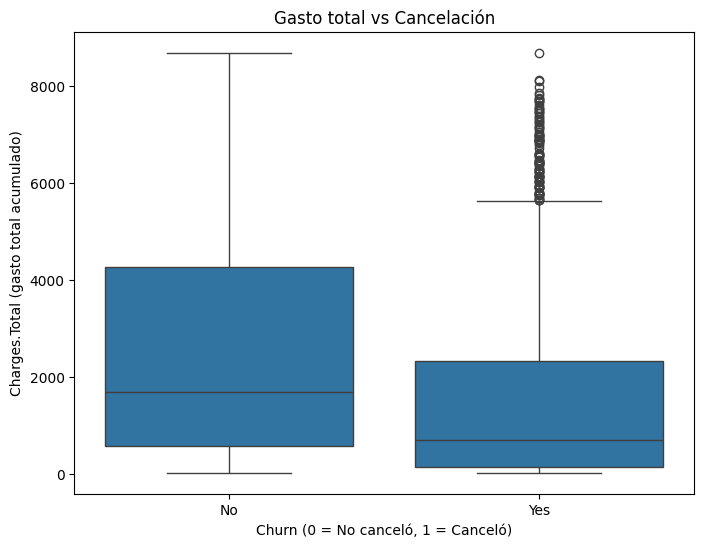

In [24]:
plt.figure(figsize=(8,6))
sns.boxplot(x=datos["Churn"], y=datos["Charges.Total"])
plt.title("Gasto total vs Cancelación")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Charges.Total (gasto total acumulado)")
plt.show()

#MODELADO PREDICTIVO

In [25]:
from sklearn.model_selection import train_test_split

X = X_encoded
y = y.map({"No": 0, "Yes": 1})  # aseguramos formato numérico

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (5634, 30)
Tamaño prueba: (1409, 30)


In [26]:
print("Distribución original:")
print(y.value_counts(normalize=True))

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True))

Distribución original:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Distribución en entrenamiento:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Distribución en prueba:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## Regresión Logística

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Escalado
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_log = log_model.predict(X_test_scaled)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_log))
print("\nReporte:\n", classification_report(y_test, y_pred_log))

Accuracy: 0.7927608232789212

Matriz de Confusión:
 [[922 113]
 [179 195]]

Reporte:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



## Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_rf))
print("\nReporte:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.7892122072391767

Matriz de Confusión:
 [[935 100]
 [197 177]]

Reporte:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



## 📊 Análisis Predictivo de Cancelación de Clientes (Churn)

### 1. Objetivo

El objetivo de este análisis fue identificar los factores que influyen en la cancelación de clientes y construir modelos predictivos capaces de anticipar qué clientes presentan mayor riesgo de abandono.

Se desarrollaron dos modelos:

* Regresión Logística (requiere normalización)
* Random Forest (no requiere normalización)

---

### 2. Evaluación de Modelos

#### 🔹 Regresión Logística

* Accuracy: 79%
* Precision (Churn): 0.63
* Recall (Churn): 0.52
* F1-score: 0.57

El modelo logra identificar el 52% de los clientes que cancelan.

---

#### 🔹 Random Forest

* Accuracy: 79%
* Precision (Churn): 0.64
* Recall (Churn): 0.47
* F1-score: 0.54

El modelo detecta el 47% de los clientes que cancelan.

---

### 3. Comparación de Modelos

Ambos modelos presentan un desempeño similar en términos de accuracy (~79%). Sin embargo, la Regresión Logística mostró mejor recall y F1-score para la clase churn.

Dado que en problemas de retención es más importante identificar correctamente a los clientes que cancelan, la Regresión Logística presenta un mejor desempeño general.

No se observan señales claras de overfitting, aunque el recall moderado sugiere posible underfitting o impacto del desbalance de clases.

---

### 4. Factores Más Influyentes en la Cancelación

A partir del análisis de coeficientes (Regresión Logística) e importancia de variables (Random Forest), se identificaron los siguientes factores clave:

#### 🔴 Factores que aumentan la cancelación:

* Servicio de Internet por Fibra Óptica
* Método de pago Electronic Check
* Altos cargos mensuales
* Baja antigüedad (tenure bajo)

#### 🟢 Factores que reducen la cancelación:

* Mayor antigüedad del cliente
* Contratos de 1 y 2 años
* Servicios adicionales como:

  * Soporte técnico
  * Seguridad online
  * Backup
  * Protección de dispositivos

La variable más importante fue **tenure**, indicando que los clientes nuevos presentan mayor riesgo de abandono.

---

### 5. Estrategias de Retención Propuestas

Basándose en los resultados obtenidos, se proponen las siguientes estrategias:

1. Implementar programas de retención temprana para clientes con menos de 12 meses.
2. Incentivar contratos de largo plazo mediante descuentos o beneficios exclusivos.
3. Revisar la estrategia de precios del servicio de fibra óptica.
4. Promover servicios adicionales que aumenten la fidelización.
5. Incentivar métodos de pago automáticos.

---

### 6. Conclusión

El análisis demuestra que la antigüedad del cliente, el tipo de contrato y los cargos mensuales son los principales determinantes de la cancelación.

La Regresión Logística fue el modelo con mejor desempeño general, aunque ambos modelos presentan oportunidades de mejora mediante técnicas de balanceo o ajuste de hiperparámetros.

La implementación de estrategias enfocadas en clientes nuevos y contratos mensuales puede reducir significativamente la tasa de cancelación.


